<a href="https://colab.research.google.com/github/seanamaennling-debug/public-utility-company-regression-model/blob/main/Quiz_8_AFM_244_(Seana_M).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Chapman Wealth Management**
# Target Corporation (Q1 & Q2) Time Series Forecasting

Seana Maennling, QuantFolio Solutions


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Assign name to dataset
qSales = pd.read_csv('qSales_2024.csv')

# Remove scientific notation
pd.options.display.float_format = '{:.2f}'.format

# Make date variable a date type
qSales['datadate'] = pd.to_datetime(qSales['datadate'])

In [ ]:
# Filter for Target
target_sales = qSales.loc[qSales['tic'] == 'TGT']

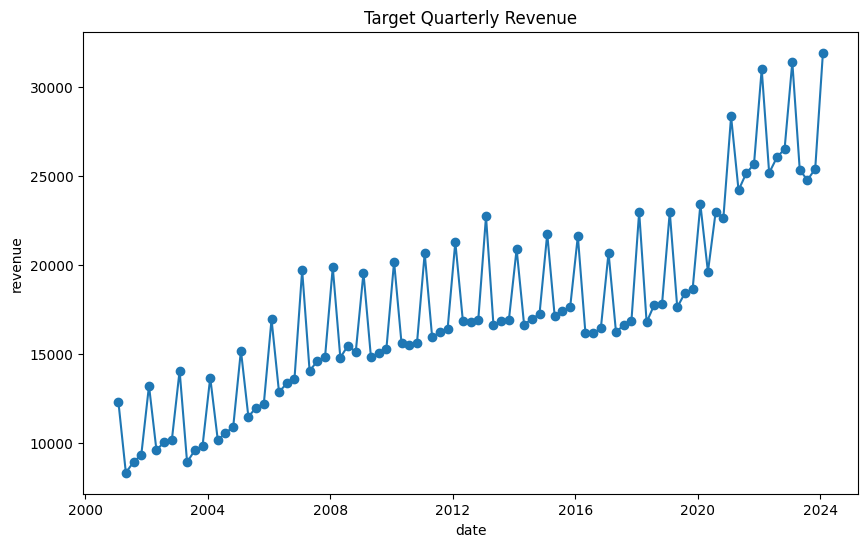

In [ ]:
# Time series forecasting

# Step 0: Visualize data to identify any patterns

plt.figure(figsize=(10,6))
plt.title('Target Quarterly Revenue')

plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(target_sales['datadate'],target_sales['saleq'],marker='o')

In [ ]:
# Step 1: Introduce time as a component in the model

target_sales['time'] = range(1, len(target_sales) + 1)
display(target_sales)

/tmp/ipykernel_8913/648030479.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['time'] = range(1, len(target_sales) + 1)


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A,1
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A,2
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A,3
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A,4
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A,89
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A,90
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A,91
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A,92


In [ ]:
# Seperate data into training and testing
# General rule of thumb is 75/25

dt4training = target_sales[:int(.75 * len(target_sales))]   # Takes first 75% of rows
dt4testing = target_sales[int(.75 * len(target_sales)):]    # Takes last 25% of rows

In [ ]:
# Training the model

y = dt4training.loc[:,'saleq']
x = dt4training.loc[:,'time']

x = sm.add_constant(x)

model1 = sm.OLS(y,x).fit()

model1.params

,0
const,10503.75
time,139.30


In [ ]:
# Get a range of values
# 1: Create new dataframe with prediction results
# 2: Get summary frame w/ a confidence level

model1_prediction_results = model1.get_prediction(x)
prediction_intervals = model1_prediction_results.summary_frame(alpha=0.2)  # 80% confidence interval

display(prediction_intervals)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
92,10643.04,560.02,9918.20,11367.89,7514.61,13771.48
93,10782.34,547.81,10073.30,11491.38,7657.53,13907.15
94,10921.64,535.69,10228.29,11614.99,7800.35,14042.92
95,11060.93,523.68,10383.13,11738.74,7943.07,14178.80
96,11200.23,511.78,10537.83,11862.63,8085.67,14314.79
...,...,...,...,...,...,...
156,19558.03,511.78,18895.63,20220.43,16443.48,22672.59
157,19697.33,523.68,19019.52,20375.13,16579.46,22815.19
158,19836.62,535.69,19143.27,20529.98,16715.34,22957.91
159,19975.92,547.81,19266.88,20684.96,16851.11,23100.73


In [ ]:
# Step 2: Introduce 2 dummy variables

# DV 1 -> Fiscal quarter 1
target_sales['Q1_dv'] = np.where(target_sales['fqtr'] == 1, 1, 0)
target_sales['Q1_interaction'] = target_sales['time'] * target_sales['Q1_dv']

# DV 2 -> Fiscal quarter 2
target_sales['Q2_dv'] = np.where(target_sales['fqtr'] == 2, 1, 0)
target_sales['Q2_interaction'] = target_sales['time'] * target_sales['Q2_dv']



/tmp/ipykernel_8913/3149531175.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['Q1_dv'] = np.where(target_sales['fqtr'] == 1, 1, 0)
/tmp/ipykernel_8913/3149531175.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['Q1_interaction'] = target_sales['time'] * target_sales['Q1_dv']
/tmp/ipykernel_8913/3149531175.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats 

In [ ]:
# Separate training and testing data again, because I added 2 dummy variables
dt4training = target_sales[:int(.75 * len(target_sales))]   # Takes first 75% of rows
dt4testing = target_sales[int(.75 * len(target_sales)):]    # Takes last 25% of rows

In [ ]:
# Step 3: Perform multiple regression modelling

# Training the model with the 2 new dummy variables
y = dt4training.loc[:,['saleq']]
x = dt4training.loc[:,['time','Q1_dv','Q1_interaction','Q2_dv','Q2_interaction']]
x = sm.add_constant(x)

model_dummy = sm.OLS(y,x).fit()

model_dummy.params


,0
const,11708.62
time,139.18
Q1_dv,-2561.27
Q1_interaction,0.54
Q2_dv,-2097.31
Q2_interaction,-6.68


In [ ]:
# Forecast values
# Prepare testing independent variables (time, dummy, interaction)
# Then use the get_prediction function to forecast the values into the testing set

x_test = dt4testing.loc[:,['time','Q1_dv','Q1_interaction','Q2_dv','Q2_interaction']]
x_test = sm.add_constant(x_test)

model_dummy.get_prediction().summary_frame(alpha=0.2)   # 80% confidence level

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
92,11847.80,688.75,10955.78,12739.82,9034.84,14660.76
93,9426.78,956.63,8187.81,10665.75,6485.34,12368.23
94,10008.82,956.63,8769.85,11247.79,7067.38,12950.26
95,12265.35,644.67,11430.41,13100.29,9469.97,15060.73
96,12404.53,630.24,11588.29,13220.78,9614.68,15194.38
...,...,...,...,...,...,...
156,20755.46,616.36,19957.20,21553.73,17970.82,23540.11
157,18368.75,956.63,17129.78,19607.71,15427.30,21310.19
158,18489.06,956.63,17250.09,19728.03,15547.62,21430.50
159,21173.01,659.66,20318.66,22027.36,18371.77,23974.25


In [ ]:
# Calculate MAPE score

model_dummy_assessment = dt4testing.copy()

model_dummy_assessment['model_dummy_predicted_revenue'] = model_dummy.predict(x_test)

model_dummy_assessment['model_dummy_abs_pct_error'] = abs((model_dummy_assessment['saleq'] - model_dummy_assessment['model_dummy_predicted_revenue'])
/model_dummy_assessment['saleq'])

model_dummy_assessment['model_dummy_abs_pct_error'].mean()


np.float64(0.12825431185427574)

Text(0.5, 0, 'time')

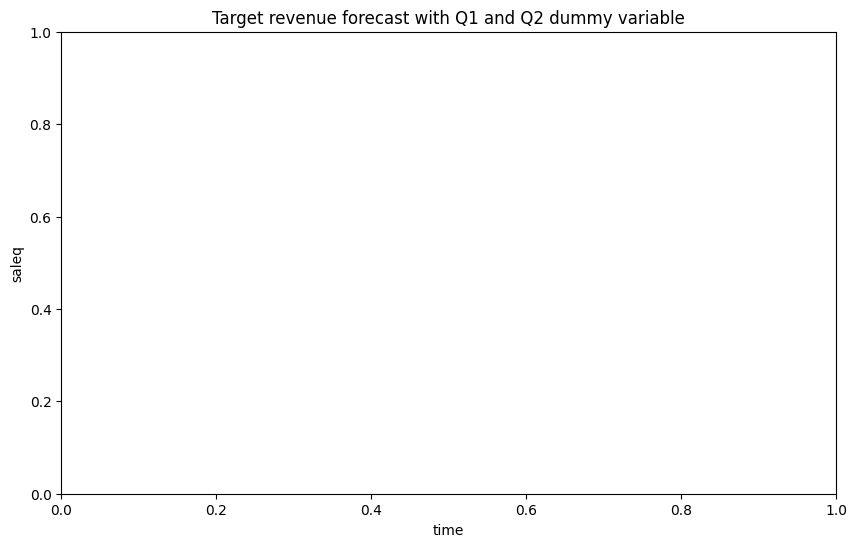

In [ ]:
# Final visualization using 2 dummy variables

plt.figure(figsize=(10,6))
plt.title('Target revenue forecast with Q1 and Q2 dummy variable')

plt.ylabel('saleq')
plt.xlabel('time')

# Unfinished visualization. Assume that Q1 sales are higher than Q2 (predicted).

# **Memorandum**

To executives at Chapman Wealth Management: please see our findings below on time series forecasting (data analytics) regarding a potential investment in Target Corporation.

We created 2 dummy variables (one for fiscal **Q1** and one for fiscal **Q2**) to analyze differences in predicted revenue for Target corp.

Our model had a MAPE score of about **12.82%**, meaning it is relatively accurate at predicting revenue.

Our recommendation is to (asusmption b/c unfinished visualization) invest in Target during Q1 because it has higher predicted sales than Q2.

If you have any questions on the above analysis, please feel free to reach out to an agent at QuantFolio Solutions, and we would be happy to help.